In [1]:
import time
import numpy as np
from examples.seismic import SeismicModel, AcquisitionGeometry, Receiver
from examples.seismic.acoustic import AcousticWaveSolver
from examples.seismic.datasets import SeismogramDataset, VelocityModel
from devito import info, TimeFunction, Function, Eq, Operator, norm, inner
from examples.seismic.utils import taper_wavelet, estimate_centroid_frequency_gather
from devito import configuration
from matplotlib import pyplot as plt
from config import setup_model_and_geometry
from config import PATH_DATA_DPLUS, TMAX, SO, PATH_DATA_DSUB
configuration["platform"] = "nvidiaX"
configuration["language"] = "openacc"
configuration["compiler"] = "nvc"
configuration["log-level"] = "ERROR"


In [2]:
from matplotlib import rc
from matplotlib import pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib.colors import ListedColormap
rc("font", family="serif")
rc("pgf", texsystem="pdflatex")
rc("text", usetex=True)
# rc('text.latex', unicode=True)
rc("text.latex", preamble=r"\usepackage{amssymb}")
rc("text.latex", preamble=r"\usepackage[T1,T2A]{fontenc}")
rc("text.latex", preamble=r"\usepackage[utf8]{inputenc}")
rc("text.latex", preamble=r"\usepackage[english,russian]{babel}")

In [3]:
model, dataset, velmodel = setup_model_and_geometry(path_data=PATH_DATA_DPLUS)
dataset._dt_r = model.critical_dt
dataset._t_max_r = TMAX
dataset.resample_on()

In [4]:
len(dataset)

55

In [5]:
print(velmodel.vp.min())
print(np.isnan(velmodel.vp))
print(velmodel.vp.shape)
from devito import mmin
print(mmin(model.vp))

0.31
[[False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]
 ...
 [False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]]
(1985, 585)
0.6000000238418579


/home/andrey/devito-vti/examples/seismic/datasets/velmodel.py:332: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(wspace=0.01)


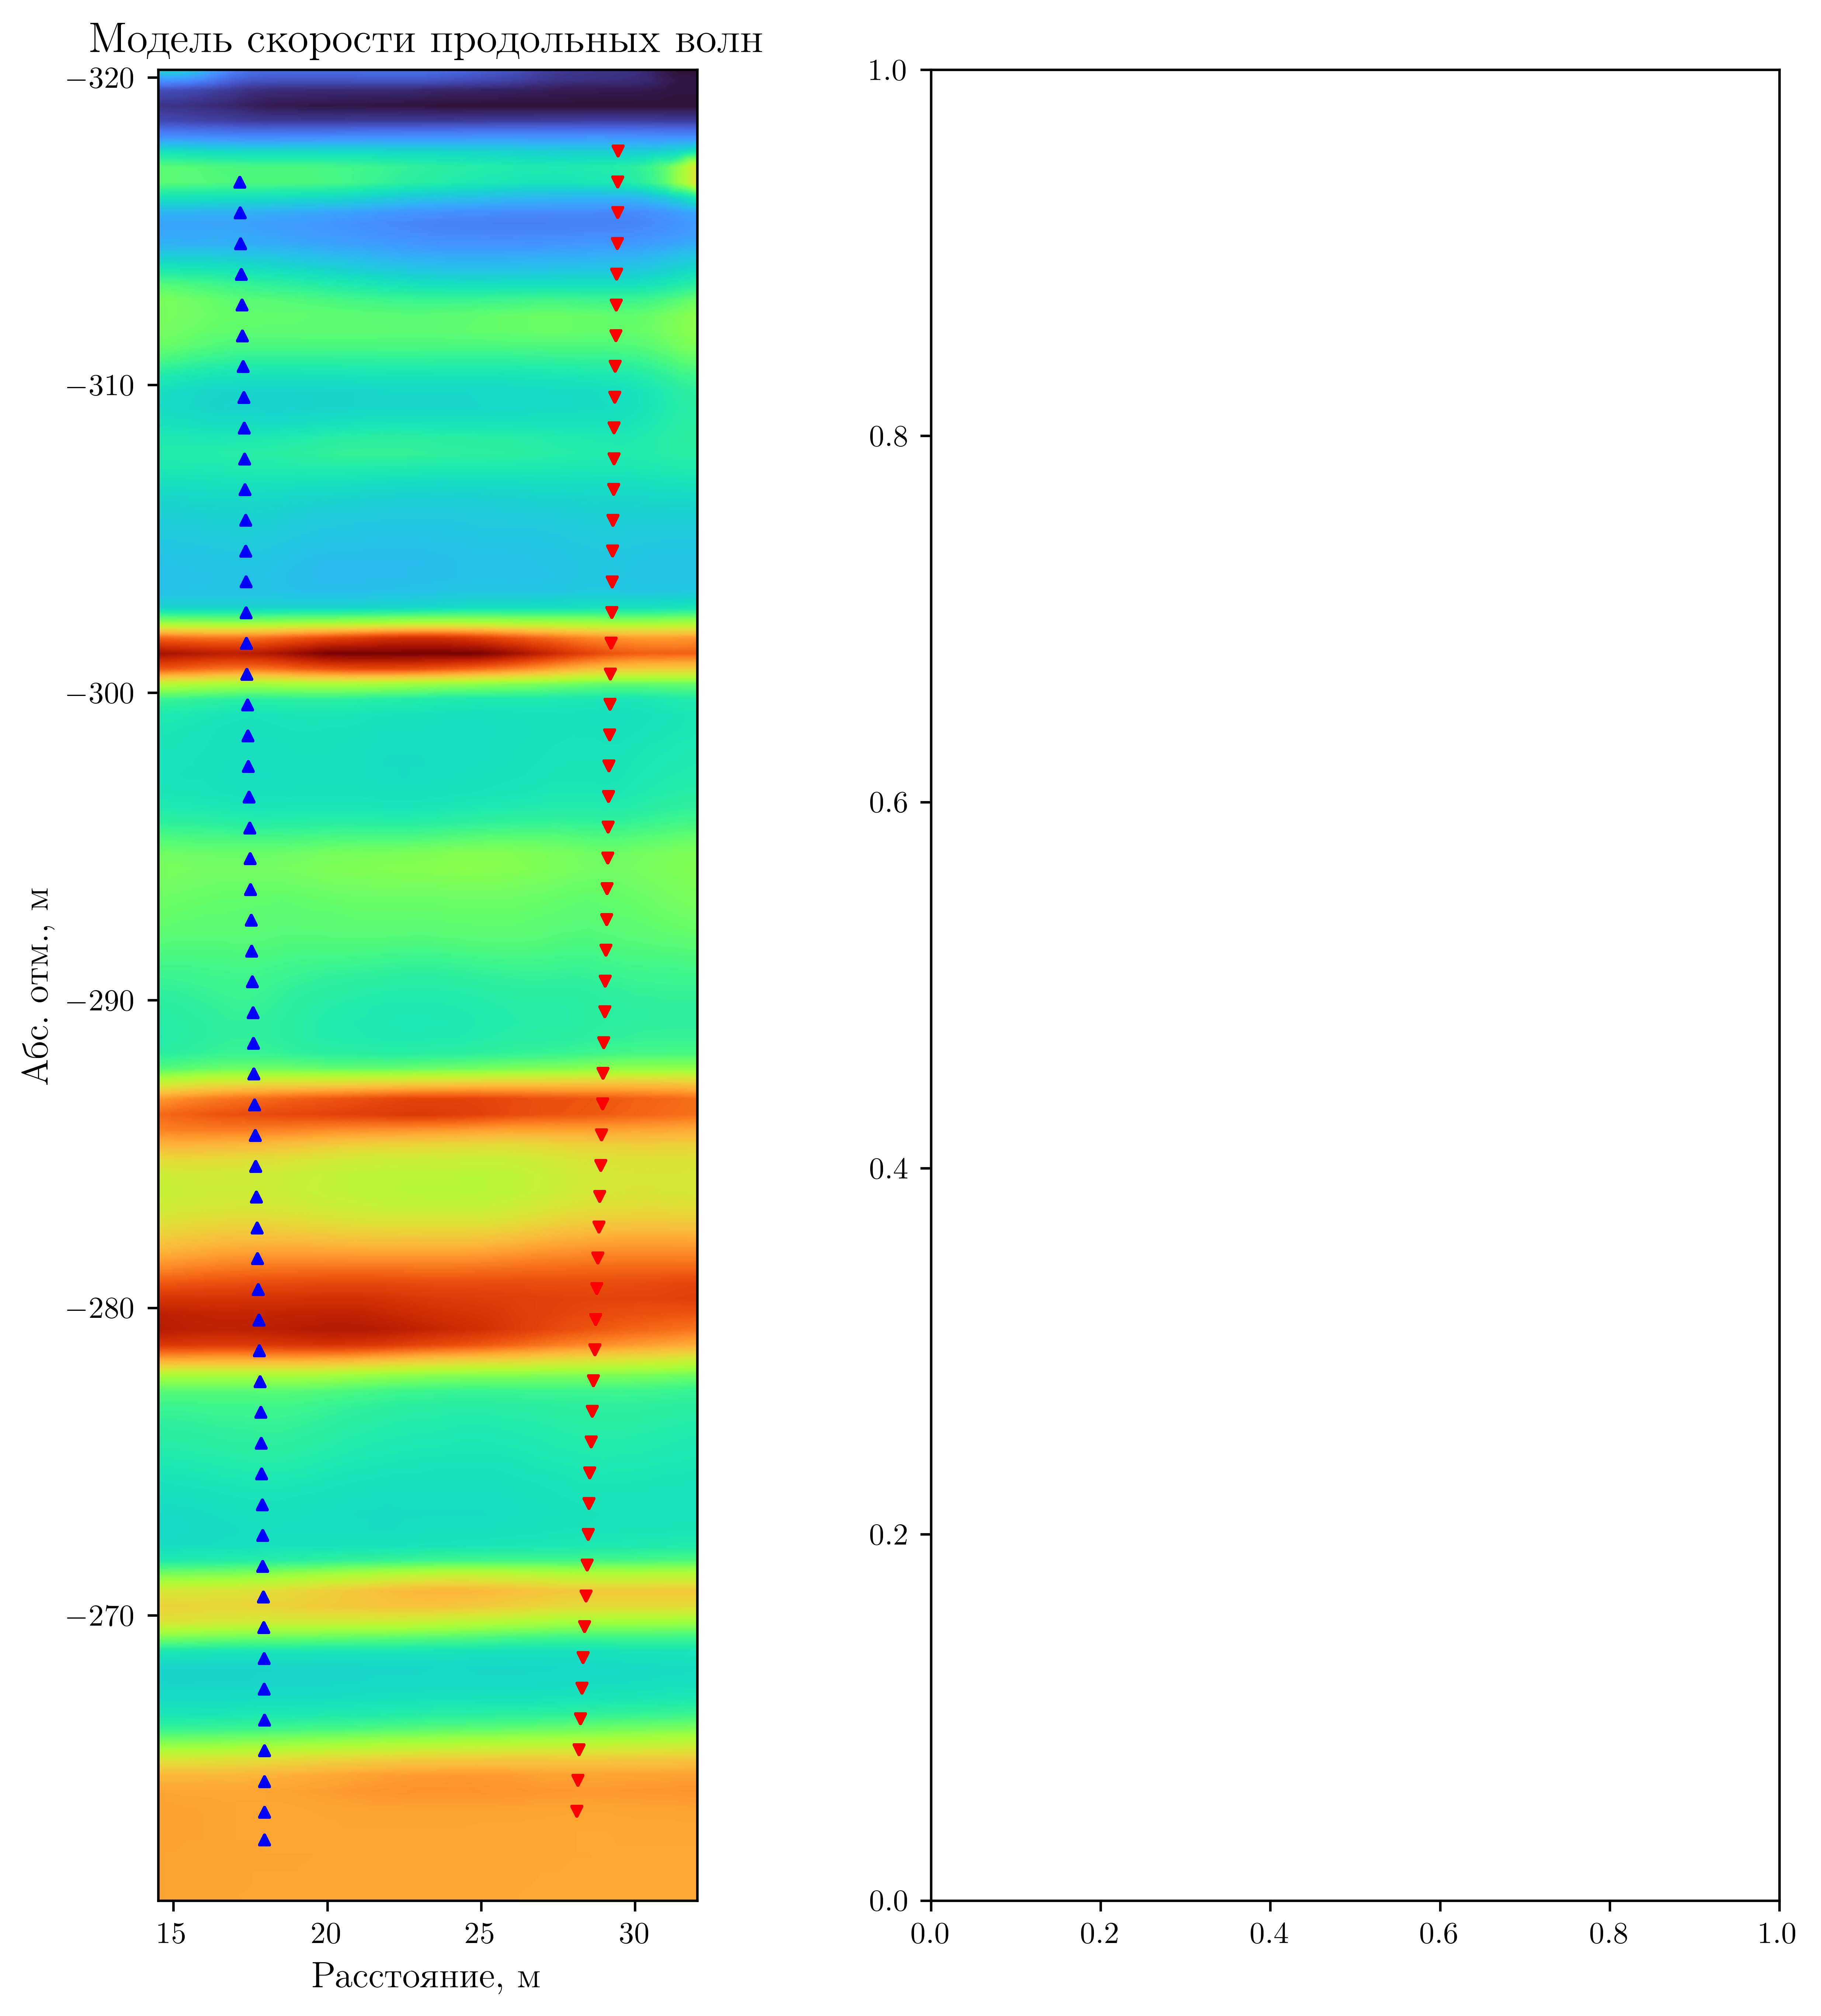

In [6]:


fig, axs = plt.subplots(1, 2, figsize=(8.2, 9), dpi=600, constrained_layout=True)
velmodel.plot_vp(show=False, axs=axs[0])

# axs[0].imshow(layered, cmap='turbo', extent=[velmodel.x[0]-velmodel.x[0], velmodel.x[-1]-velmodel.x[0], -velmodel.z[-1], -velmodel.z[0]], vmin=0.5, vmax=5.5)
# im1 = axs[1].imshow(layered_gal, cmap='turbo', extent=[velmodel.x[0]-velmodel.x[0], velmodel.x[-1]-velmodel.x[0], -velmodel.z[-1], -velmodel.z[0]], vmin=0.5, vmax=5.5)



axs[0].scatter(dataset.x_coords, dataset.elevations, c='r', s=10, marker='v', zorder=50)
axs[0].scatter(dataset.opposite_x, dataset.opposite_elev, c='b', s=10, marker='^', zorder=50)


axs[0].set_xlabel("Расстояние, м")
plt.show()

In [7]:
from devito import mmin
print(velmodel.vp.min())
print(mmin(model.vp))

0.31
0.6000000238418579


In [8]:
print(model.shape)

(585, 1985)


In [9]:
print(model.critical_dt)

0.00289


In [10]:
d_obs, sx, sz, rec_x, rec_z = dataset[20]

t0 = 0
tn = TMAX

src_pos = np.array([sx, sz])[None, :]
rec_pos = np.vstack([rec_x, rec_z]).T
geometry = AcquisitionGeometry(
    model, rec_pos, src_pos,
    t0, tn, f0=0.25, src_type='Ricker'
)
solver = AcousticWaveSolver(model, geometry, space_order=SO)
d_syn = Receiver(name='d_syn', grid=model.grid, time_range=geometry.time_axis,
                     coordinates=geometry.rec_positions)
solver.forward(vp=model.vp, save=False, rec=d_syn)
residual = Receiver(name='residual', grid=model.grid, time_range=geometry.time_axis,
                coordinates=geometry.rec_positions)
residual.data[:] = d_syn.data[:] - d_obs.T
srca, v, summary = solver.adjoint(vp=model.vp, rec=residual)

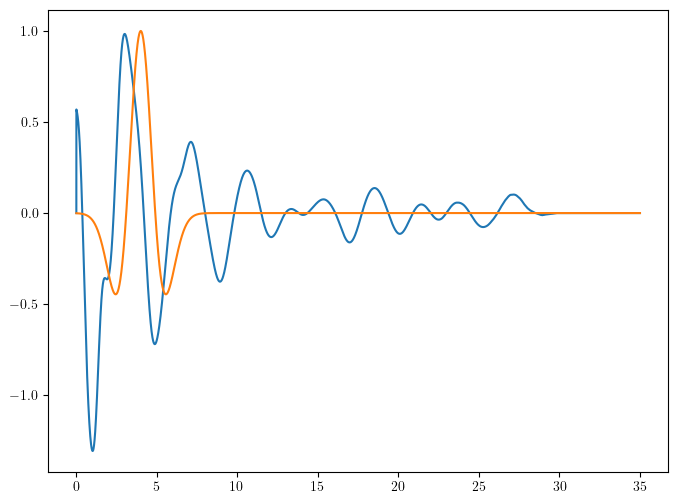

In [14]:
plt.plot(geometry.time_axis.time_values, srca.data[:]*300000)
plt.plot(geometry.time_axis.time_values, geometry.src.data[:])
plt.show()

In [15]:
def calculate_step_size(misfit, h):
    # Compute numerator and denominator for step size
    numerator = np.dot(misfit.reshape(-1), h.reshape(-1))
    denominator = np.dot(h.reshape(-1), h.reshape(-1))
    return numerator / denominator

from scipy.signal.windows import tukey

def left_taper_tukey(signal, alpha=0.5):
    """
    Taper the left side of a signal using a Tukey window.
    
    Args:
        signal (np.ndarray): Input signal (gradient).
        alpha (float): Shape parameter of the Tukey window (0=rectangular, 1=Hann).
    
    Returns:
        np.ndarray: Tapered signal.
    """
    n = len(signal)
    signal[0] = 0.
    window = tukey(n * 2, alpha=alpha)[:n]  # Take left half of symmetric window
    return signal * window, window

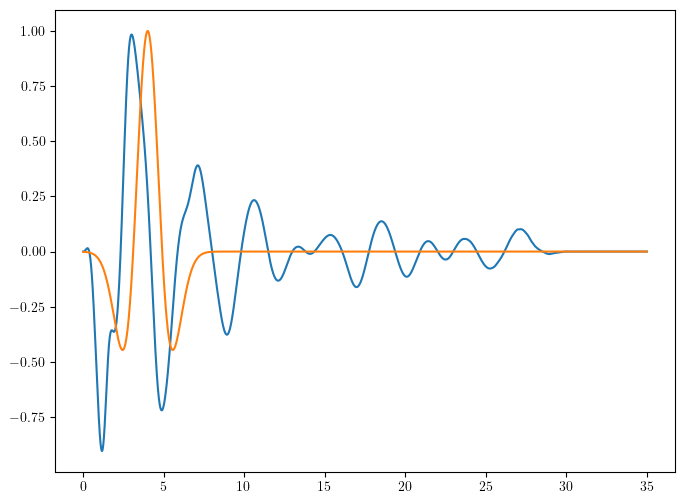

In [18]:
plt.plot(geometry.time_axis.time_values, left_taper_tukey(srca.data[:].reshape(-1)*300000, alpha=0.05)[0])
plt.plot(geometry.time_axis.time_values, geometry.src.data[:])
plt.show()

Iter 3: Alpha = 2584.9381491287045 Misfit = 5.3633e+03
Scale:  535.7338642180849 0.008105129178731981 0.0067492051935864085
Iter 4: Alpha = 658.1921415434364 Misfit = 2.5446e+03


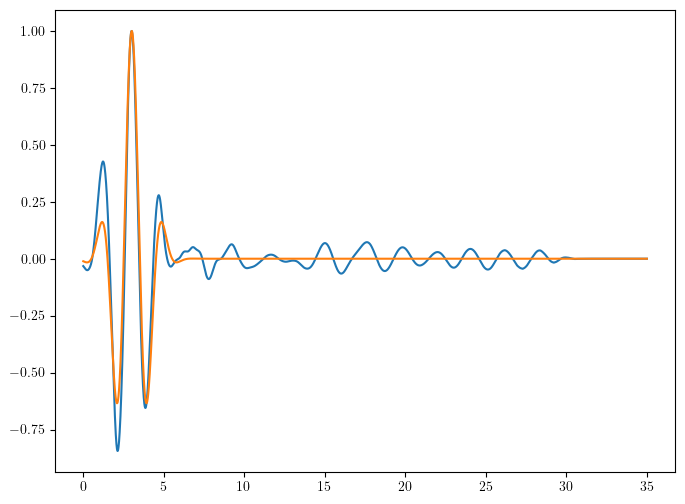

Estimated gather centroid frequency: 515.27 Hz, Wavelet length: 1.94 ms
Scale:  286.21124716271584 0.006447551116310711 0.006955894217301277
Iter 0: Alpha = 14987.723158913828 Misfit = 8.8542e+04
Scale:  398.62046552851416 0.006447551116310711 0.004621062655622307
Iter 1: Alpha = 1341.1063463830371 Misfit = 1.1012e+04
Scale:  515.1227127178777 0.006447551116310711 0.0059014232615628055
Iter 2: Alpha = 4297.400988766698 Misfit = 8.5489e+03
Scale:  421.0461999892249 0.006447551116310711 0.004298539461545304
Iter 3: Alpha = 788.3196173558514 Misfit = 3.9944e+03
Scale:  659.7520049893535 0.006447551116310711 0.006057967858596506
Iter 4: Alpha = 3039.172344455817 Misfit = 3.1778e+03


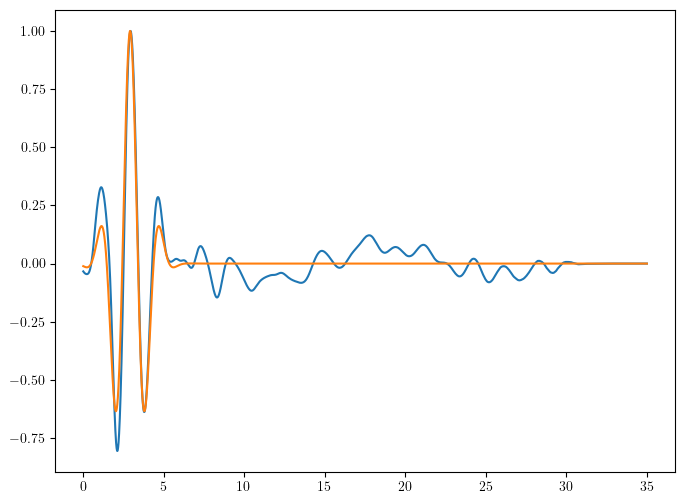

Estimated gather centroid frequency: 515.70 Hz, Wavelet length: 1.94 ms
Scale:  418.77150193886513 0.010143995756293742 0.00857680822845144
Iter 0: Alpha = 10556.604424643612 Misfit = 8.8390e+04
Scale:  532.7391105106096 0.010143995756293742 0.006650645690684823
Iter 1: Alpha = 949.1928165228285 Misfit = 1.5373e+04
Scale:  695.6270354704338 0.010143995756293742 0.007537703207493388
Iter 2: Alpha = 4112.075292895144 Misfit = 1.2467e+04
Scale:  572.1589187063903 0.010143995756293742 0.006494403908956318
Iter 3: Alpha = 589.8053898112561 Misfit = 5.4636e+03
Scale:  871.4939934400604 0.010143995756293742 0.008652050138845149
Iter 4: Alpha = 1958.7584383968929 Misfit = 4.4853e+03


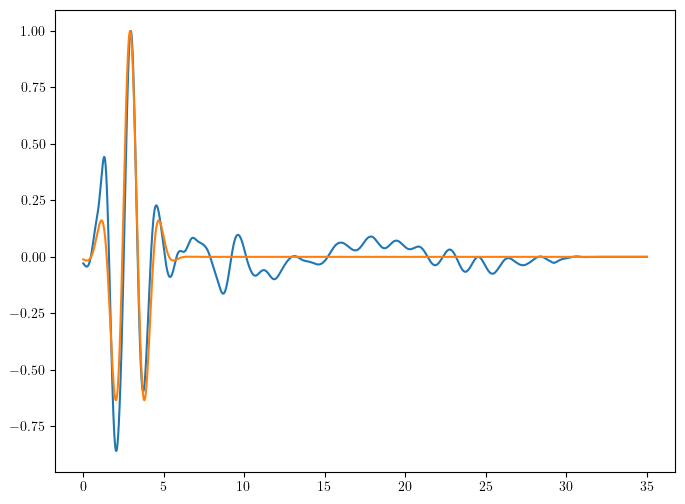

Estimated gather centroid frequency: 483.41 Hz, Wavelet length: 2.07 ms
Scale:  370.4455716392743 0.009426032797921112 0.007482325739857024
Iter 0: Alpha = 9595.881745570634 Misfit = 1.0059e+05
Scale:  510.36890675534414 0.009426032797921112 0.006005791138779118
Iter 1: Alpha = 1302.372074662193 Misfit = 1.4120e+04
Scale:  655.4106747420411 0.009426032797921112 0.006905705803380313
Iter 2: Alpha = 2414.896580430012 Misfit = 9.9435e+03
Scale:  591.905678233617 0.009426032797921112 0.005641290267451095
Iter 3: Alpha = 738.2061732028086 Misfit = 5.3301e+03
Scale:  869.2339475089635 0.009426032797921112 0.00720301375025308
Iter 4: Alpha = 4979.833041774105 Misfit = 4.0849e+03


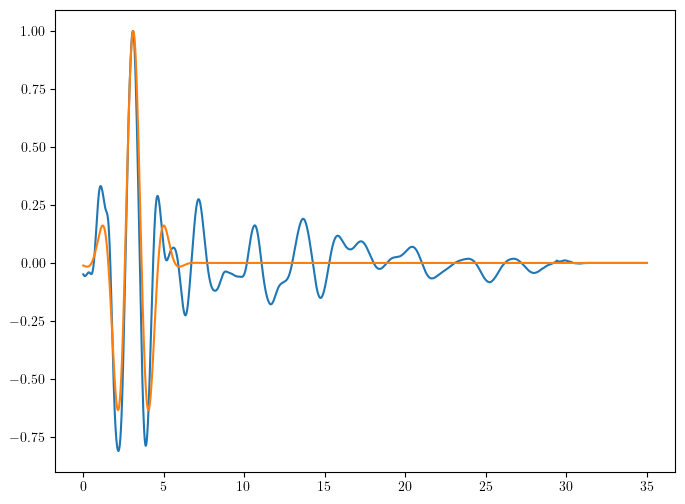

Estimated gather centroid frequency: 486.71 Hz, Wavelet length: 2.05 ms
Scale:  408.78362453378867 0.00918359495612938 0.007004152817969235
Iter 0: Alpha = 9547.615712817205 Misfit = 9.9234e+04
Scale:  451.5364310029059 0.00918359495612938 0.006160757459214625
Iter 1: Alpha = 1207.7720905104156 Misfit = 2.3295e+04
Scale:  636.7399986742209 0.00918359495612938 0.005997945121442817
Iter 2: Alpha = 5564.295263158128 Misfit = 1.7947e+04
Scale:  590.4356091844753 0.00918359495612938 0.0065867918700968624
Iter 3: Alpha = 847.64526099667 Misfit = 5.9543e+03
Scale:  872.3419462125443 0.00918359495612938 0.007949820779913679
Iter 4: Alpha = 2929.7303474131145 Misfit = 4.6083e+03


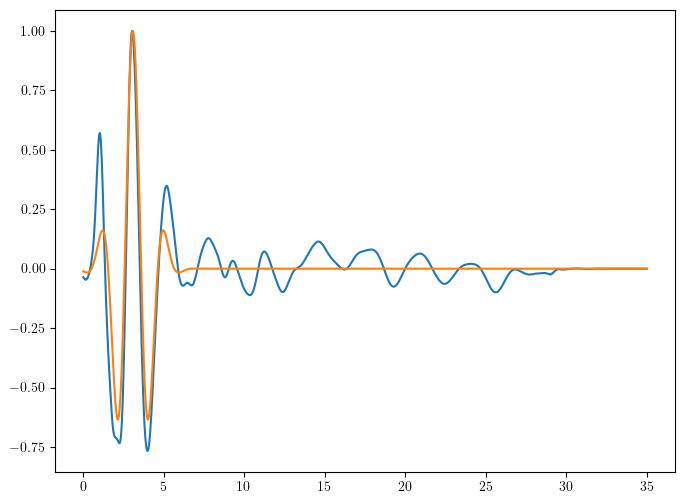

Estimated gather centroid frequency: 516.01 Hz, Wavelet length: 1.94 ms
Scale:  367.7534587353533 0.009060278117531918 0.007910715677377883
Iter 0: Alpha = 10502.056679355803 Misfit = 8.8285e+04
Scale:  480.8241815060983 0.009060278117531918 0.0056173734277200115
Iter 1: Alpha = 1498.9734473858891 Misfit = 1.6114e+04
Scale:  632.5926812812406 0.009060278117531918 0.007400604239043041
Iter 2: Alpha = 4958.902593675794 Misfit = 1.1704e+04
Scale:  598.4148931089941 0.009060278117531918 0.006098137039460967
Iter 3: Alpha = 787.1899384201022 Misfit = 4.0821e+03
Scale:  888.8174187143987 0.009060278117531918 0.007559386977228046
Iter 4: Alpha = 3505.902969711117 Misfit = 3.1437e+03


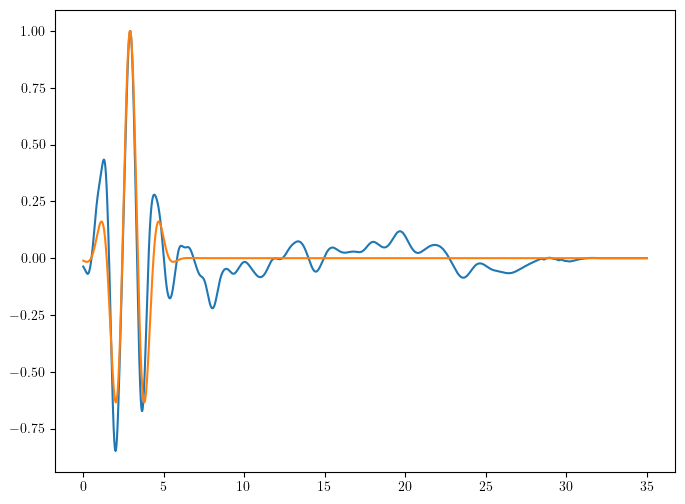

Estimated gather centroid frequency: 495.79 Hz, Wavelet length: 2.02 ms
Scale:  241.72561092120444 0.0060074593428833065 0.006220284536019264
Iter 0: Alpha = 13913.048297179063 Misfit = 9.5634e+04
Scale:  378.6880837243661 0.0060074593428833065 0.0044973368476067385
Iter 1: Alpha = 2883.5582609271783 Misfit = 1.0887e+04
Scale:  470.84749071316304 0.0060074593428833065 0.0060132369844105235
Iter 2: Alpha = 3164.3305246310865 Misfit = 6.0123e+03
Scale:  520.4768977708817 0.0060074593428833065 0.0045677719786724295
Iter 3: Alpha = 1838.1334254189273 Misfit = 2.9629e+03
Scale:  665.5193063797324 0.0060074593428833065 0.006086181419538027
Iter 4: Alpha = 2794.792730630586 Misfit = 1.7755e+03


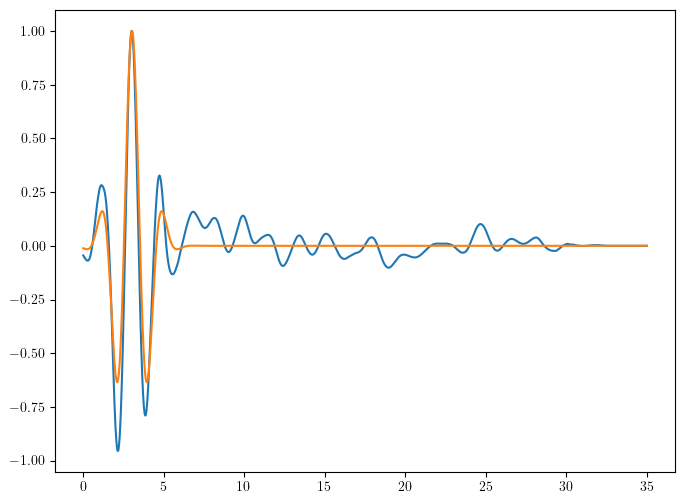

Estimated gather centroid frequency: 506.73 Hz, Wavelet length: 1.97 ms
Scale:  242.32295288651588 0.006061075051376053 0.005957298360025893
Iter 0: Alpha = 15483.177548804864 Misfit = 9.1553e+04
Scale:  353.3547794315667 0.006061075051376053 0.004238841527995679
Iter 1: Alpha = 3880.2010678158717 Misfit = 1.6696e+04
Scale:  412.3878952791694 0.006061075051376053 0.005677110646738981
Iter 2: Alpha = 3667.2650755314944 Misfit = 1.0146e+04
Scale:  462.00526326928883 0.006061075051376053 0.004419229208693913
Iter 3: Alpha = 2998.9950126874683 Misfit = 6.1852e+03
Scale:  527.1629059932527 0.006061075051376053 0.005700600747698309
Iter 4: Alpha = 2750.8186485176125 Misfit = 3.8836e+03


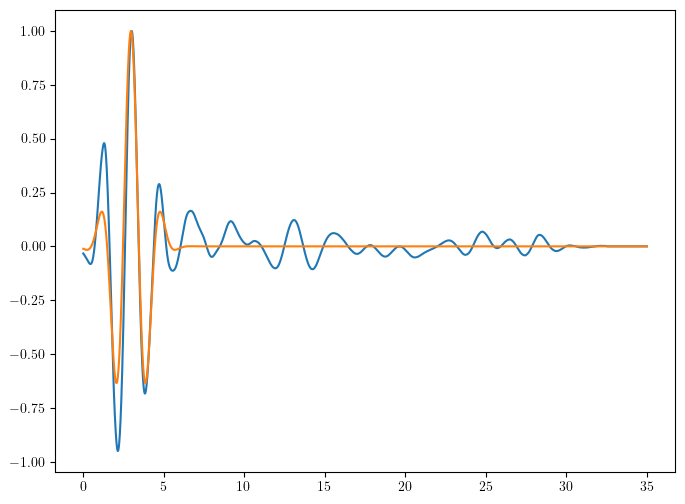

Estimated gather centroid frequency: 494.77 Hz, Wavelet length: 2.02 ms
Scale:  113.55358690117403 0.0026082923662635953 0.0027547490758760007
Iter 0: Alpha = 36324.23420579519 Misfit = 9.6036e+04
Scale:  163.60286763350751 0.0026082923662635953 0.0019421901222683047
Iter 1: Alpha = 9843.969305370887 Misfit = 1.8363e+04
Scale:  192.80263018194813 0.0026082923662635953 0.0026549891677245664
Iter 2: Alpha = 8980.18662180773 Misfit = 1.0870e+04
Scale:  219.19839595548675 0.0026082923662635953 0.002076973845317275
Iter 3: Alpha = 7440.406402216121 Misfit = 6.5618e+03
Scale:  249.60263749422268 0.0026082923662635953 0.002649632806605558
Iter 4: Alpha = 6668.2830906815825 Misfit = 4.0697e+03


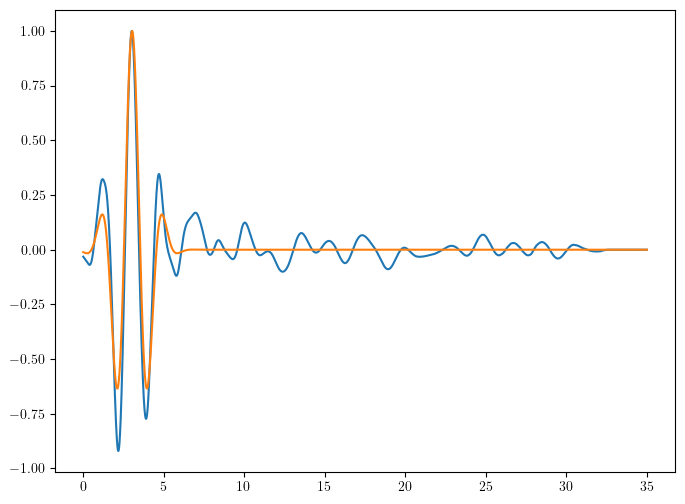

In [ ]:
max_iter = 5
beta = 1e-6
for k in range(len(dataset)):
    d_obs, sx, sz, rec_x, rec_z = dataset[k]
    f0 = estimate_centroid_frequency_gather(d_obs.T, model.critical_dt) / 1e3
    print(f"Estimated gather centroid frequency: {f0*1e3:.2f} Hz, Wavelet length: {1/f0:.2f} ms")
    src_pos = np.array([sx, sz])[None, :]
    rec_pos = np.vstack([rec_x, rec_z]).T
    geometry = AcquisitionGeometry(
        model, rec_pos, src_pos,
        t0, tn, f0=f0 * 2, src_type='Gabor'
    )
    current_wavelet = geometry.src.data[:].reshape(-1)
    initial_wavelet = np.copy(current_wavelet)
    scale_factor = 1.
    for i in range(max_iter):
        # Forward modeling
        geometry = AcquisitionGeometry(
            model, rec_pos, src_pos,
            t0, tn, f0=0.25, src_type=None, wav_data=current_wavelet
        )
        solver = AcousticWaveSolver(model, geometry, space_order=SO)
        d_syn = Receiver(name='d_syn', grid=model.grid, time_range=geometry.time_axis,
                        coordinates=geometry.rec_positions)
        solver.forward(vp=model.vp, rec=d_syn, save=False)
        residual = Receiver(name='residual', grid=model.grid, time_range=geometry.time_axis,
                    coordinates=geometry.rec_positions)
        # if i == 0:
        scale_factor = np.linalg.norm(d_obs.ravel())/np.linalg.norm(np.array(d_syn.data[:]).ravel())
        print("Scale: ", scale_factor, np.quantile(d_obs, 0.99), scale_factor*np.quantile(np.array(d_syn.data[:]), 0.99))
        residual.data[:] = scale_factor*d_syn.data - d_obs.T
        
        # Compute gradient (adjoint source)
        srca, _, _ = solver.adjoint(vp=model.vp, rec=residual)
        gradient = srca.data
        gradient_tapered, window = left_taper_tukey(gradient.reshape(-1), alpha=0.05)
        gradient_tapered += beta*(current_wavelet - initial_wavelet)
        misfit = geometry.src.data.reshape(-1) - gradient_tapered.reshape(-1)
        alpha = 0.5*calculate_step_size(misfit, gradient)
        # Update wavelet
        current_wavelet = current_wavelet - alpha * gradient_tapered
        print(f"Iter {i}: Alpha = {alpha} Misfit = {np.dot(misfit.reshape(-1), misfit.reshape(-1))**2:.4e}")
    plt.plot(geometry.time_axis.time_values, current_wavelet/np.max(np.abs(current_wavelet)))
    plt.plot(geometry.time_axis.time_values, initial_wavelet/np.max(np.abs(initial_wavelet)))
    plt.show()
    np.save(f"../adjoint_wavelets2/wavelet_{k}_norm.npy", current_wavelet)
    np.save(f"../adjoint_wavelets2/wavelet_scale_{k}.npy", scale_factor)

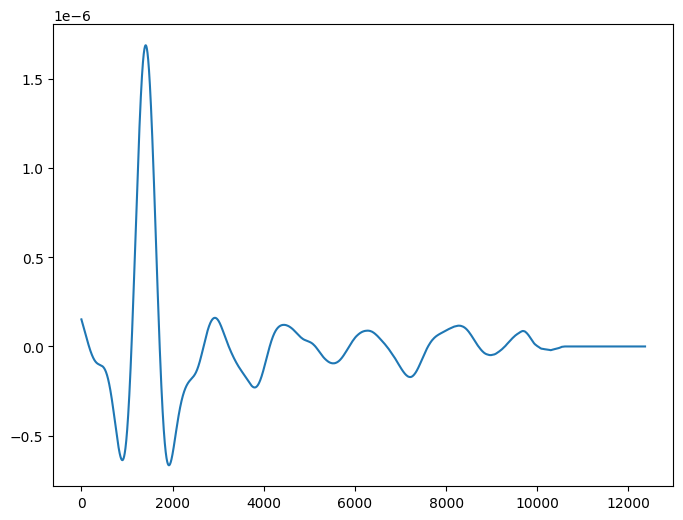

In [47]:
# plt.imshow(d_syn.data[:], aspect='auto')
# plt.imshow(d_obs.T, aspect='auto')

plt.plot(srca.data[:][1:])

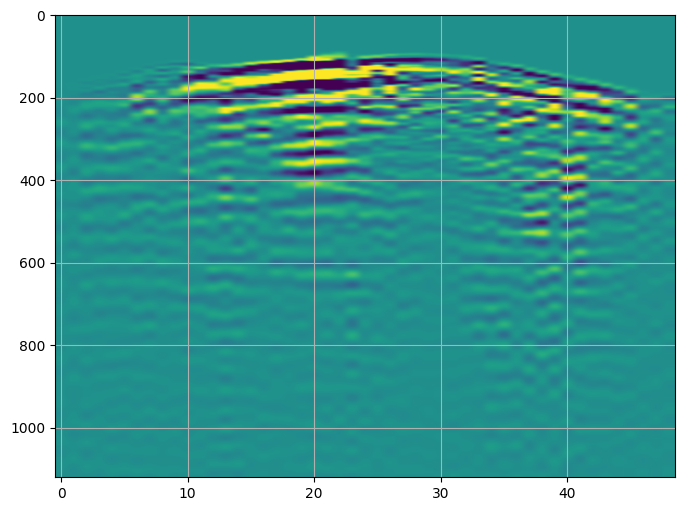

In [8]:

d_obs, sx, sz, rec_x, rec_z = dataset[20]
qa = np.quantile(d_obs, 0.99)

plt.imshow(d_obs.T, aspect='auto', vmin=-qa, vmax=qa)
plt.grid()
plt.show()

Operator `Forward` ran in 4.04 s


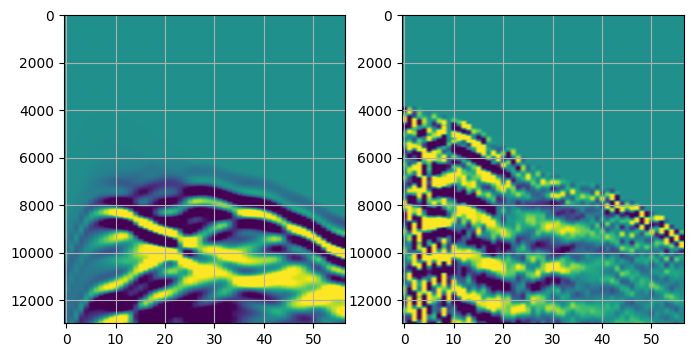

Operator `Forward` ran in 4.04 s


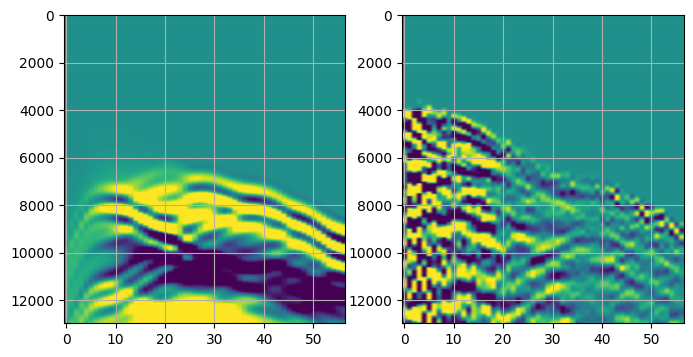

Operator `Forward` ran in 4.04 s


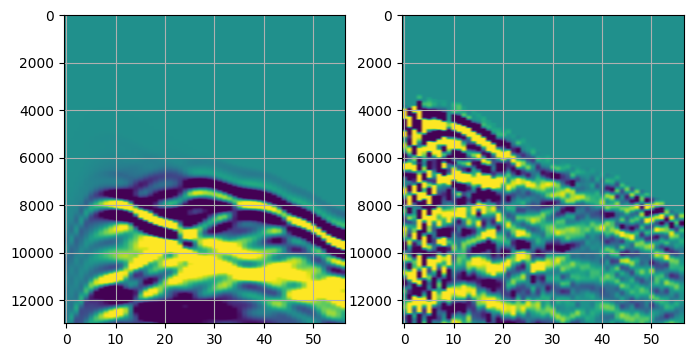

Operator `Forward` ran in 4.04 s


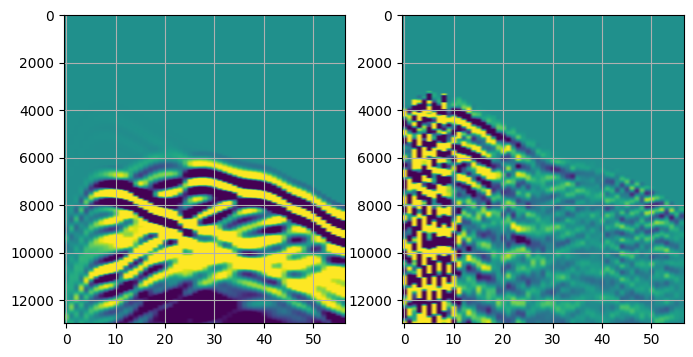

In [ ]:
N = 40
t0 = 0
tn = TMAX
for i in range(len(dataset)):
    d_obs, sx, sz, rec_x, rec_z = dataset[i]
    wav_data = np.load(f"Mex_wavelet_{i}_norm.npy")
    src_pos = np.array([sx, sz])[None, :]
    rec_pos = np.vstack([rec_x, rec_z]).T
    geometry = AcquisitionGeometry(
        model, rec_pos, src_pos,
        t0, tn, f0=0.25, src_type=None, wav_data=wav_data
    )
    solver = AcousticWaveSolver(model, geometry, space_order=SO)
    d_syn = Receiver(name='d_syn', grid=model.grid, time_range=geometry.time_axis,
                        coordinates=geometry.rec_positions)
    solver.forward(vp=model.vp, save=False, rec=d_syn)
    scale_factor = np.linalg.norm(d_obs.ravel())/np.linalg.norm(np.array(d_syn.data[:]).ravel())
    np.save(f"Mex_wavelet_{i}_norm_scalar.npy", scale_factor)
    
    fig, axs = plt.subplots(1, 2, figsize=(8, 4))
    qa = np.quantile(d_obs, 0.95)
    axs[0].imshow(scale_factor*d_syn.data[:], aspect='auto', vmin=-qa, vmax=qa)
    axs[0].grid()
    axs[1].imshow(d_obs.T, aspect='auto', vmin=-qa, vmax=qa)
    axs[1].grid()
    plt.show()
# srca, v, summary = solver.adjoint(vp=model.vp, rec=residual)

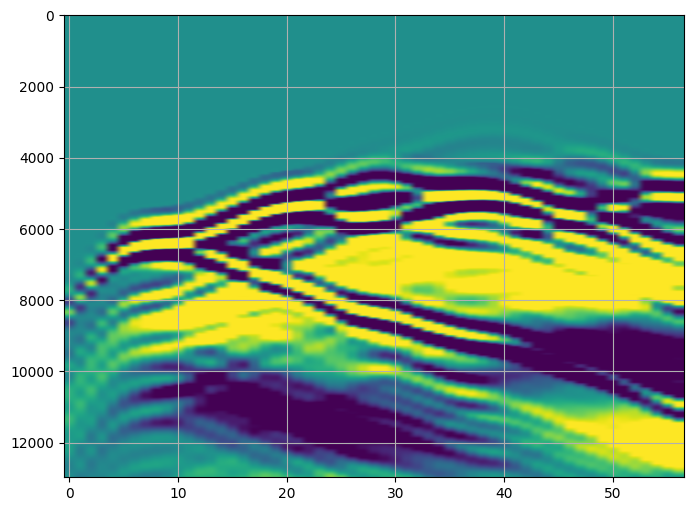

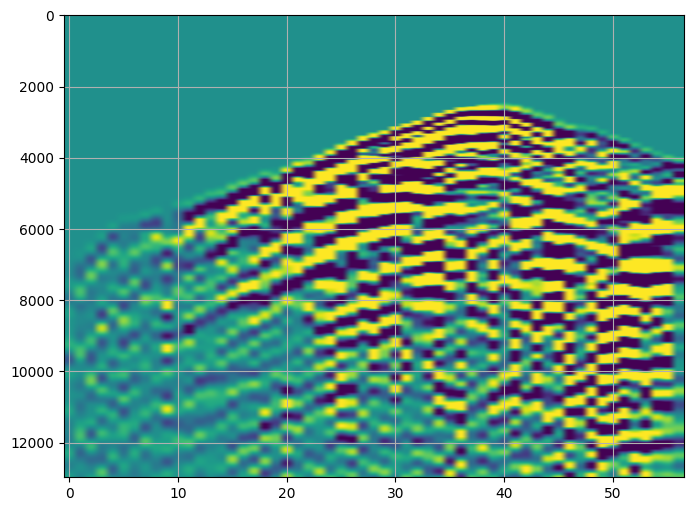

In [12]:
from matplotlib import pyplot as plt
# d_obs, sx, sz, rec_x, rec_z = dataset[20]
qa = np.quantile(d_obs, 0.9)
# qa = np.quantile(np.array(d_syn.data[:]).ravel(), 0.99)
plt.imshow(d_syn.data[:], aspect='auto', vmin=-qa, vmax=qa)
plt.grid()
plt.show()
plt.imshow(d_obs.T, aspect='auto', vmin=-qa, vmax=qa)
plt.grid()
plt.show()